In [3]:
import numpy as np
import statsmodels as sm

In [14]:
# consider an example data set:
import pandas as pd
path_to_data = "/home/jwalitnpanchal/college_work/sem10/ML_AI/regularization/Amazon.csv"
student_data = pd.read_csv(path_to_data)
print(student_data,"\n",student_data.columns)

                           date        open        high         low  \
0     1997-05-15 00:00:00-04:00    0.121875    0.125000    0.096354   
1     1997-05-16 00:00:00-04:00    0.098438    0.098958    0.085417   
2     1997-05-19 00:00:00-04:00    0.088021    0.088542    0.081250   
3     1997-05-20 00:00:00-04:00    0.086458    0.087500    0.081771   
4     1997-05-21 00:00:00-04:00    0.081771    0.082292    0.068750   
...                         ...         ...         ...         ...   
6981  2025-02-13 00:00:00-05:00  228.850006  230.419998  227.520004   
6982  2025-02-14 00:00:00-05:00  229.199997  229.889999  227.229996   
6983  2025-02-18 00:00:00-05:00  228.820007  229.300003  223.720001   
6984  2025-02-19 00:00:00-05:00  225.520004  226.830002  223.710007   
6985  2025-02-20 00:00:00-05:00  224.779999  225.130005  221.809998   

           close   adj_close      volume  
0       0.097917    0.097917  1443120000  
1       0.086458    0.086458   294000000  
2       0.085417  

In [73]:
# choose 2 coloumns for linear regression
p1 = "open"
p2 = "high"
r1 = "close"
predictor1 = student_data[p1]
predictor2 = student_data[p2]
response = student_data[r1]

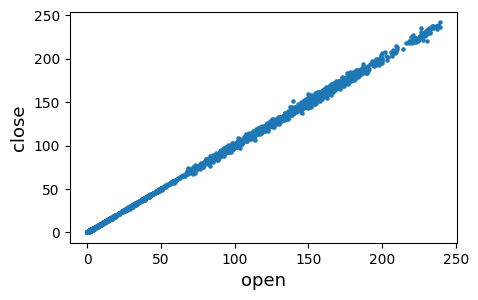

In [74]:
# plot a scatter plot
import matplotlib.pyplot as plt
figsize=(5,3)
plt.figure(1, figsize=figsize)
plt.scatter(predictor1, response, s=5.0)
plt.xlabel(c1, fontsize=13)
plt.ylabel(c2, fontsize=13)
plt.show()

In [75]:
# doing ridge regularization
# forming the x matrix
x = np.zeros((predictor1.shape[0],3))
x[:,0] = 1.0
x[:,1] = predictor1[:]
x[:,2] = predictor2[:]
# forming the y and beta matrix
y = np.zeros(response.shape[0])
y[:] = response[:]
beta = np.zeros(3)

In [76]:
# find the least squares solution to the over determined system
import numpy as np
def least_squares_solution(x:np.ndarray, y:np.ndarray, lambda_ridge:float=1.0):
    xtx = x.T @ x
    for i in range(xtx.shape[0]):
        xtx[i,i] = xtx[i,i] + lambda_ridge
    # do svd
    u, s, vt = np.linalg.svd
    return

In [77]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
selected_cols = [p1,p2]
parameter_variable    =    np.asarray(np.column_stack([student_data[data] for data in selected_cols]))
sm_para_variable = sm.add_constant(parameter_variable)
#parameter_variable = np.column_stack([predictor1,predictor2])
print(sm_para_variable, "\n", sm_para_variable.shape)
X_train, X_test, y_train, y_test = train_test_split(sm_para_variable, np.asarray(response), test_size=0.2, random_state=42)

[[1.00000000e+00 1.21875003e-01 1.25000000e-01]
 [1.00000000e+00 9.84380022e-02 9.89580005e-02]
 [1.00000000e+00 8.80210027e-02 8.85419995e-02]
 ...
 [1.00000000e+00 2.28820007e+02 2.29300003e+02]
 [1.00000000e+00 2.25520004e+02 2.26830002e+02]
 [1.00000000e+00 2.24779999e+02 2.25130005e+02]] 
 (6986, 3)


In [78]:
model    =    sm.OLS(X_train, y_train)
# ridge regression
ridge_model    =    model.fit_regularized(method='elastic_net', alpha=1.0, L1_wt=0.0)

In [79]:
print(ridge_model.params.shape, type(ridge_model.params))

(1, 3) <class 'numpy.ndarray'>


In [80]:
alphas = [0.0, 1.0, 10.0, 100.0, 1000.0,]
beta0 = []
beta1 = []
beta2 = []
for alpha in alphas:
    ridge_model_loop = model.fit_regularized(method="elastic_net", alpha=alpha, L1_wt=0.0)
    beta0.append(ridge_model_loop.params[0,0])
    beta1.append(ridge_model_loop.params[0,1])
    beta2.append(ridge_model_loop.params[0,2])
print(beta0, "\n", beta1, "\n", beta2)

[np.float64(0.008043407907343618), np.float64(0.00804182238482586), np.float64(0.008027580760895395), np.float64(0.007887890569151696), np.float64(0.006718743164815776)] 
 [np.float64(1.0005325250319888), np.float64(1.0003352993203922), np.float64(0.9985637606746034), np.float64(0.9811874716839728), np.float64(0.8357553342031897)] 
 [np.float64(1.0115918554396015), np.float64(1.0113924497046125), np.float64(1.0096013294553041), np.float64(0.9920329726244007), np.float64(0.8449933091311735)]


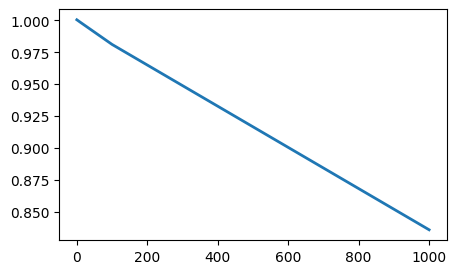

In [81]:
plt.figure(2, figsize=figsize)
plt.plot(alphas, beta1, lw=2.0, label=r"$\beta_{0}$")
plt.show()